# 🔗 Live Deployment: https://heart-disease-hunain-uci.streamlit.app/

# Heart Disease Prediction System

## Setup: Running This Notebook From Scratch

Follow these steps in a terminal, inside this project's folder, before opening the notebook.

### 1. Check Python is installed
```
python --version
```
Any Python 3.9-3.13 should work.

### 2. Create a virtual environment
**Windows:** `python -m venv venv`  |  **macOS / Linux:** `python3 -m venv venv`

### 3. Activate the virtual environment
**Windows (Command Prompt):** `venv\Scripts\activate.bat`
**Windows (PowerShell):** `venv\Scripts\Activate.ps1`
*(If PowerShell blocks this, run once: `Set-ExecutionPolicy -Scope CurrentUser RemoteSigned`)*
**macOS / Linux:** `source venv/bin/activate`

### 4. Install the required packages
```
pip install -r requirements.txt
```

### 5. Register the virtual environment as a Jupyter kernel (recommended)
```
python -m ipykernel install --user --name=heart-venv --display-name "Python (heart-venv)"
```
Then select **Kernel -> Change Kernel -> Python (heart-venv)**.

### 6. Launch Jupyter Notebook
```
jupyter notebook
```
Open this `.ipynb` file and run **Kernel -> Restart & Run All**.

### 7. When you're done
```
deactivate
```

## Assignment Information

| | |
|---|---|
| **Course** | Machine Learning Fundamentals (AIC354) — Assignment 2 |
| **Task** | Task 2: Heart Disease Prediction System (built by modifying the Titanic Passenger Survival Prediction code) |
| **Student** | Hunain — FA24-BSE-083, Section B |
| **Instructor** | Dr. Rao Muhammad Adeel Nawab |
| **University** | COMSATS University Islamabad, Lahore Campus |

The Titanic notebook was modified **step by step, keeping exactly the same structure**: Import Libraries → Load Data → Understand & Pre-process → Label Encode → Train → Test → Application → Feedback → Deploy.

## SU Meta Description
<p>
Discover the Heart Disease Prediction System, a machine learning model that analyzes a patient's gender, exercise-induced angina, ST depression and number of blocked vessels to predict the presence of heart disease.
</p>

## Introduction

##### **Definition** A binary classification ML task that predicts whether a patient has heart disease (Yes) or does not have heart disease (No) from four clinical attributes.
##### **Application** Used for learning data science and for illustrating how clinical measurements relate to heart disease. **It is an educational model and not a medical diagnostic tool.**

## Input and Output

### Inputs (Features / Attributes)
Only **4 input attributes** were selected from the UCI Heart Disease dataset (as required by the assignment):

| **Input Feature/Attribute** | **Original UCI Column** | **Possible Values** |
| --- | --- | --- |
| **Gender** | `sex` | Male, Female |
| **ExerciseAngina** | `exang` (exercise-induced angina) | No, Yes |
| **STDepression** | `oldpeak` (ST depression induced by exercise relative to rest) | Absent (0), Mild (> 0 to 1.5), High (> 1.5) |
| **Vessels** | `ca` (number of major vessels coloured by fluoroscopy) | Zero, One, Two, Three |

### Output (Prediction)

| **Output Attribute** | **Original UCI Column** | **Possible Values** |
| --- | --- | --- |
| **HeartDisease** | `num` | Yes, No |

### Examples (Heart Disease Dataset)

| Gender | ExerciseAngina | STDepression | Vessels | HeartDisease |
| :---: | :---: | :---: | :---: | :---: |
| Male | Yes | Mild | One | Yes |
| Male | No | Mild | Zero | Yes |
| Male | No | Mild | One | No |
| Female | Yes | High | Two | Yes |
| Female | No | Absent | One | No |

## Developer & System Information

| | |
|---|---|
| **Developer Name** | Hunain (FA24-BSE-083) |
| **Program Name** | heart_disease_project |
| **IDE** | Jupyter Notebook |
| **Programming Language** | Python 3 |
| **Libraries** | NumPy 2.2.6, Pandas 2.3.3, Pickle (built-in), scikit-learn 1.7.2, PrettyTable 3.18.0, Matplotlib 3.10.9, Seaborn 0.13.2 |
| **Dataset** | UCI Machine Learning Repository — Heart Disease (Cleveland), https://archive.ics.uci.edu/dataset/45/heart+disease |
| **Deployment** | Streamlit Community Cloud |

## Dataset Notes (please read)

- **Source:** UCI Machine Learning Repository *Heart Disease* dataset (https://archive.ics.uci.edu/dataset/45/heart+disease), the **Cleveland** file `processed.cleveland.data` (303 patients, 13 attributes + outcome `num`). The raw copy (with column names added) is included as `heart-disease-original-cleveland.csv`.
- **Missing values:** 6 patients have a missing value (`?` in `ca` or `thal`); `ca` is one of our inputs, so these **6 rows were removed**, leaving **297 patients**.
- **4 attributes selected** out of 13 (assignment constraint): `sex`, `exang`, `oldpeak`, `ca`. They were chosen because their meaning is clear and they give a good cross-validated accuracy (about 78%) with the same SVC model.
- **Converted to labels** exactly like the Titanic data (text categories instead of numbers): `sex` 1/0 → Male/Female, `exang` 1/0 → Yes/No, `oldpeak` binned into Absent (0) / Mild (up to 1.5) / High (above 1.5), `ca` 0-3 → Zero/One/Two/Three.
- **Output label:** `num` is 0 for no disease and 1-4 for disease, so it was converted to a binary label: `HeartDisease = Yes` when `num` is 1-4 (137 patients) and `No` when `num` is 0 (160 patients).
- **Train/test split:** same 80/20 call as the Titanic notebook (`random_state=0`), plus `shuffle=True` and `stratify` on the output so that both parts keep the same share of patients with and without heart disease.

##  Table of Content
- Step 1: Import Libraries
- Step 2: Load Sample Data
- Step 3: Understand and Pre-process Sample Data
  - Step 3.1: Understand Sample Data
  - Step 3.2: Pre-process Sample Data
  - Step 3.3: Visualize Heart Disease by Gender and Vessels
- Step 4: Feature Extraction
- Step 5: Label Encoding the Sample Data
  - Step 5.1: Train the Label Encoder
  - Step 5.2: Label Encode the Output
  - Step 5.3: Label Encode the Input
- Step 6: Execute the Training Phase
  - Step 6.1: Splitting Sample Data into Training Data and Testing Data
  - Step 6.2: Splitting Input Vectors and Outputs / Labels of Training Data
  - Step 6.3: Train the Support Vector Classifier
  - Step 6.4: Save the Trained Model
  - Step 6.5: Compare SVC vs. Logistic Regression vs. Decision Tree
- Step 7: Execute the Testing Phase
  - Step 7.1 - 7.5: Split, Load Model, Predict, Accuracy, Detailed Metrics
- Step 8: Execute the Application Phase
- Step 9: Execute the Feedback Phase
- Step 10: Deploy Your Model as a Public Web App

## Code – Heart Disease Prediction

### Step 1: Import Libraries

In [1]:
"""
Purpose of this code:
----------------------
Imports the libraries needed to build and evaluate the machine learning model:
data handling, preprocessing, splitting, the SVM model, metrics and plotting.
"""

import numpy as np                                   # numerical computing
import pandas as pd                                  # DataFrames, reading/writing data
import pickle                                        # saving and loading the trained model
from sklearn.model_selection import train_test_split # split data into training and testing sets
from sklearn.preprocessing import LabelEncoder       # categorical values -> numeric codes
from sklearn import svm                              # Support Vector Machine model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from prettytable import PrettyTable                  # clean table output
import matplotlib.pyplot as plt                      # plotting
import seaborn as sns

# Additional models used for the classifier comparison in Step 6.5
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

### Step 2: Load Sample Data

In [2]:
"""
Purpose of this section:
-------------------------
Loads the sample dataset (4 input attributes + output) from a CSV file into a
pandas DataFrame and displays it.
"""

# 'sample-data.csv' must be present in the working directory
sample_data = pd.read_csv("sample-data.csv")

print("\n\nSample Data:")
print("============\n")

# Show the first and last rows (the dataset has 297 rows)
pd.set_option("display.max_rows", 20, "display.max_columns", None)
print(sample_data)



Sample Data:

     Gender ExerciseAngina STDepression Vessels HeartDisease
0    Female             No       Absent    Zero           No
1      Male             No       Absent     One          Yes
2    Female             No       Absent    Zero           No
3      Male             No         High   Three          Yes
4      Male             No         Mild    Zero           No
..      ...            ...          ...     ...          ...
292    Male             No       Absent    Zero           No
293    Male             No         Mild     Two          Yes
294    Male             No         Mild     One          Yes
295    Male             No         Mild     Two          Yes
296  Female             No       Absent     One           No

[297 rows x 5 columns]


### Step 3: Understand and Pre-process Sample Data

#### Step 3.1: Understand Sample Data

In [3]:
"""
Purpose of this section:
-------------------------
1. Print the names of all attributes (columns).
2. Show the total number of instances (rows).
3. Check for missing values and the class distribution.
"""

print("\n\nAttributes in Sample Data:")
print("==========================\n")
print(sample_data.columns)

print("\n\nNumber of Instances in Sample Data:", sample_data["Gender"].count())
print("========================================\n")

print("Missing values per attribute:")
print(sample_data.isnull().sum())

print("\nClass distribution (HeartDisease):")
print(sample_data["HeartDisease"].value_counts())



Attributes in Sample Data:

Index(['Gender', 'ExerciseAngina', 'STDepression', 'Vessels', 'HeartDisease'], dtype='object')


Number of Instances in Sample Data: 297

Missing values per attribute:
Gender            0
ExerciseAngina    0
STDepression      0
Vessels           0
HeartDisease      0
dtype: int64

Class distribution (HeartDisease):
HeartDisease
No     160
Yes    137
Name: count, dtype: int64


#### Step 3.2: Pre-process Sample Data
o   Sample Data is already Preprocessed (the 4 attributes were selected from the UCI dataset, converted into text labels, the output was converted so that *Yes = heart disease*, the 6 rows with missing values were removed, and there are no missing values)

o   No further Preprocessing needs to be Performed

#### Step 3.3: Visualize Heart Disease by Gender and Vessels

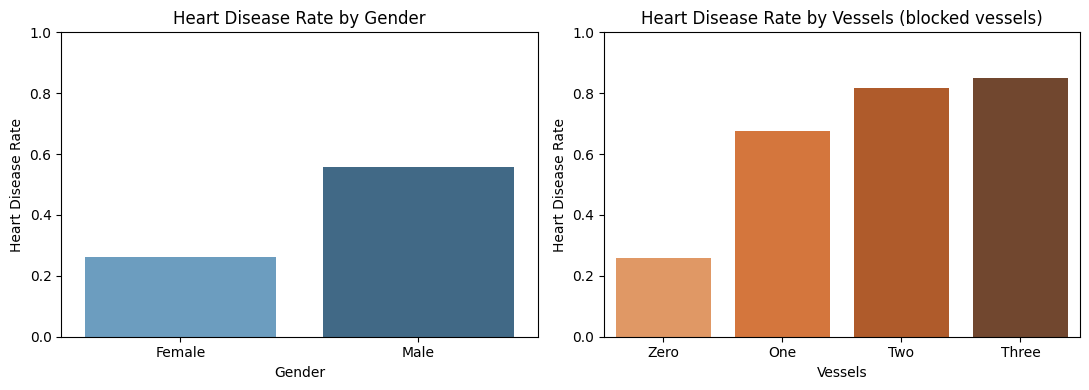

Observation: Males and patients with more coloured vessels have a clearly higher heart disease rate.
This is why Gender and Vessels are useful input features for the model.


In [4]:
"""
Purpose of this section:
-------------------------
Before training, SEE why these attributes are useful predictors: plot the
fraction of patients WITH heart disease for each Gender and each Vessels value.
"""

df_plot = sample_data.assign(DiseaseNum=(sample_data["HeartDisease"] == "Yes").astype(int))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

gender_rate = df_plot.groupby("Gender")["DiseaseNum"].mean()
sns.barplot(x=gender_rate.index, y=gender_rate.values, ax=axes[0], hue=gender_rate.index, legend=False, palette="Blues_d")
axes[0].set_title("Heart Disease Rate by Gender")
axes[0].set_ylabel("Heart Disease Rate")
axes[0].set_ylim(0, 1)

vessel_order = ["Zero", "One", "Two", "Three"]
vessel_rate = df_plot.groupby("Vessels")["DiseaseNum"].mean().reindex(vessel_order)
sns.barplot(x=vessel_rate.index, y=vessel_rate.values, ax=axes[1], hue=vessel_rate.index, legend=False, palette="Oranges_d")
axes[1].set_title("Heart Disease Rate by Vessels (blocked vessels)")
axes[1].set_ylabel("Heart Disease Rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("Observation: Males and patients with more coloured vessels have a clearly higher heart disease rate.")
print("This is why Gender and Vessels are useful input features for the model.")

#### Step 4: Feature Extraction
o   Features are already Extracted

o   No Feature Extraction needs to be Performed

### Step 5: Label Encoding the Sample Data (Input and Output is converted in Numeric Representation)

#### Step 5.1: Train the Label Encoder

In [5]:
"""
Purpose of this section:
-------------------------
Sets up and trains Label Encoders, which convert categorical values
(e.g. 'Male', 'Female', 'Zero', 'One') into numeric codes.

Steps:
1. Define the possible categories of each attribute.
2. Initialize a LabelEncoder for each attribute.
3. Train (fit) each LabelEncoder with its categories.
"""

gender = pd.DataFrame({"Gender": ["Male", "Female"]})
exercise_angina = pd.DataFrame({"ExerciseAngina": ["No", "Yes"]})
st_depression = pd.DataFrame({"STDepression": ["Absent", "Mild", "High"]})
vessels = pd.DataFrame({"Vessels": ["Zero", "One", "Two", "Three"]})
heart_disease = pd.DataFrame({"HeartDisease": ["Yes", "No"]})

gender_label_encoder = LabelEncoder()
exercise_angina_label_encoder = LabelEncoder()
st_depression_label_encoder = LabelEncoder()
vessels_label_encoder = LabelEncoder()
heart_disease_label_encoder = LabelEncoder()

# np.ravel() flattens the DataFrame column into a 1D array for the encoder
gender_label_encoder.fit(np.ravel(gender))
exercise_angina_label_encoder.fit(np.ravel(exercise_angina))
st_depression_label_encoder.fit(np.ravel(st_depression))
vessels_label_encoder.fit(np.ravel(vessels))
heart_disease_label_encoder.fit(np.ravel(heart_disease))

# LabelEncoder numbers categories in alphabetical order - show the learned codes
for name, enc in [("Gender", gender_label_encoder), ("ExerciseAngina", exercise_angina_label_encoder),
                  ("STDepression", st_depression_label_encoder), ("Vessels", vessels_label_encoder),
                  ("HeartDisease", heart_disease_label_encoder)]:
    print(f"{name:15s}", {c: int(i) for i, c in enumerate(enc.classes_)})

Gender          {'Female': 0, 'Male': 1}
ExerciseAngina  {'No': 0, 'Yes': 1}
STDepression    {'Absent': 0, 'High': 1, 'Mild': 2}
Vessels         {'One': 0, 'Three': 1, 'Two': 2, 'Zero': 3}
HeartDisease    {'No': 0, 'Yes': 1}


#### Step 5.2: Label Encode the Output

In [6]:
"""
Purpose of this section:
-------------------------
Applies Label Encoding to the output variable ("HeartDisease"):
"Yes"/"No" are converted into 1/0.
"""

sample_data_encoded_output = sample_data.copy()
original_sample_data = sample_data.copy()

print("\n\nHeartDisease Attribute After Label Encoding:")
print("============================================\n")
sample_data["encoded_heartdisease"] = heart_disease_label_encoder.transform(sample_data["HeartDisease"])
print(sample_data[["HeartDisease", "encoded_heartdisease"]])

sample_data_encoded_output[["Gender", "ExerciseAngina", "STDepression", "Vessels", "HeartDisease"]] = \
    sample_data[["Gender", "ExerciseAngina", "STDepression", "Vessels", "encoded_heartdisease"]]

sample_data_encoded_output.to_csv(r"sample-data-encoded-output.csv", index=False, header=True)
print("\nSaved: sample-data-encoded-output.csv")



HeartDisease Attribute After Label Encoding:

    HeartDisease  encoded_heartdisease
0             No                     0
1            Yes                     1
2             No                     0
3            Yes                     1
4             No                     0
..           ...                   ...
292           No                     0
293          Yes                     1
294          Yes                     1
295          Yes                     1
296           No                     0

[297 rows x 2 columns]

Saved: sample-data-encoded-output.csv


#### Step 5.3: Label Encode the Input

In [7]:
"""
Purpose of this section:
-------------------------
Applies Label Encoding to the 4 input attributes so the ML model can process them.
"""

sample_data_encoded = sample_data_encoded_output.copy()

sample_data_encoded_output["encoded_gender"] = gender_label_encoder.transform(sample_data_encoded_output["Gender"])
sample_data_encoded_output["encoded_exerciseangina"] = exercise_angina_label_encoder.transform(sample_data_encoded_output["ExerciseAngina"])
sample_data_encoded_output["encoded_stdepression"] = st_depression_label_encoder.transform(sample_data_encoded_output["STDepression"])
sample_data_encoded_output["encoded_vessels"] = vessels_label_encoder.transform(sample_data_encoded_output["Vessels"])

sample_data_encoded[["Gender", "ExerciseAngina", "STDepression", "Vessels", "HeartDisease"]] = \
    sample_data_encoded_output[["encoded_gender", "encoded_exerciseangina", "encoded_stdepression", "encoded_vessels", "HeartDisease"]]

print("\n\nSample Data after Label Encoding:")
print("=================================\n")
print(sample_data_encoded)

sample_data_encoded.to_csv(r"sample-data-encoded.csv", index=False, header=True)



Sample Data after Label Encoding:

     Gender  ExerciseAngina  STDepression  Vessels  HeartDisease
0         0               0             0        3             0
1         1               0             0        0             1
2         0               0             0        3             0
3         1               0             1        1             1
4         1               0             2        3             0
..      ...             ...           ...      ...           ...
292       1               0             0        3             0
293       1               0             2        2             1
294       1               0             2        0             1
295       1               0             2        2             1
296       0               0             0        0             0

[297 rows x 5 columns]


### Step 6: Execute the Training Phase

#### Step 6.1: Splitting Sample Data into Training Data and Testing Data

In [8]:
"""
Purpose of this section:
-------------------------
Splits the dataset into Training Data (80%, used to teach the model) and
Testing Data (20%, used to check performance on unseen data).
Same call as the Titanic notebook, with one addition: shuffle=True together with
stratify=... so that the training and testing parts keep the same ratio of
patients with / without heart disease (the classes are not perfectly balanced).
"""

training_data_encoded, testing_data_encoded = train_test_split(
    sample_data_encoded,
    test_size=0.2,
    random_state=0,
    shuffle=True,
    stratify=sample_data_encoded["HeartDisease"]
)

training_data_encoded.to_csv(r"training-data-encoded.csv", index=False, header=True)
testing_data_encoded.to_csv(r"testing-data-encoded.csv", index=False, header=True)

print("Training Data shape:", training_data_encoded.shape)
print("Testing Data shape:", testing_data_encoded.shape)

Training Data shape: (237, 5)
Testing Data shape: (60, 5)


### Step 6.2: Splitting Input Vectors and Outputs / Labels of Training Data

In [9]:
"""
Purpose of this section:
-------------------------
Separates the features (input vectors) from the labels (outputs) of the training data.
"""

input_vector_train = training_data_encoded.iloc[:, :-1]
output_label_train = training_data_encoded.iloc[:, -1]

print("Input vectors (train) shape:", input_vector_train.shape)
print("Output labels (train) shape:", output_label_train.shape)

Input vectors (train) shape: (237, 4)
Output labels (train) shape: (237,)


### 6.3: Train the Support Vector Classifier

In [10]:
"""
Purpose of this section:
-------------------------
Trains a Support Vector Classifier (SVC) on the training data. The SVC finds the
best boundary separating the classes (heart disease vs. no heart disease).
"""

print("\n\nTraining the Support Vector Classifier on Training Data")
print("========================================================\n")

svc_model = svm.SVC(gamma="auto", random_state=0)
svc_model.fit(input_vector_train, np.ravel(output_label_train))

print(svc_model)



Training the Support Vector Classifier on Training Data

SVC(gamma='auto', random_state=0)


### Step 6.4: Save the Trained Model

In [11]:
"""
Purpose of this section:
-------------------------
Saves the trained SVC model so it can be reused (and deployed) without retraining.
"""

pickle.dump(svc_model, open("svc_trained_model.pkl", "wb"))
print("Saved: svc_trained_model.pkl")

Saved: svc_trained_model.pkl


### Step 6.5: Compare SVC vs. Logistic Regression vs. Decision Tree


Model Comparison on Testing Data:
+---------------------+----------+-----------+--------+----------+
|        Model        | Accuracy | Precision | Recall | F1-score |
+---------------------+----------+-----------+--------+----------+
|   SVC (gamma=auto)  |   0.8    |    0.8    |  0.8   |   0.8    |
| Logistic Regression |   0.7    |    0.7    |  0.7   |   0.7    |
|    Decision Tree    |   0.82   |    0.82   |  0.82  |   0.82   |
+---------------------+----------+-----------+--------+----------+


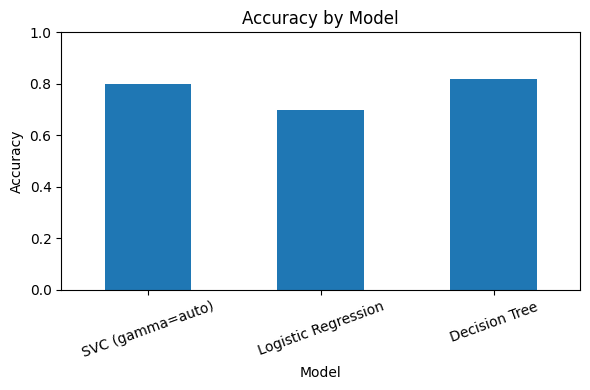

In [12]:
"""
Purpose of this section:
-------------------------
Trains two additional classifiers on the SAME training data and compares all three
on the testing data. The model that is SAVED and DEPLOYED is still the SVC.
"""

input_vector_test = testing_data_encoded.iloc[:, :-1]
output_label_test = testing_data_encoded.iloc[:, -1]

candidate_models = {
    "SVC (gamma=auto)": svc_model,
    "Logistic Regression": LogisticRegression(random_state=0, max_iter=1000).fit(input_vector_train, np.ravel(output_label_train)),
    "Decision Tree": DecisionTreeClassifier(random_state=0).fit(input_vector_train, np.ravel(output_label_train)),
}

comparison_rows = []
for name, mdl in candidate_models.items():
    preds = mdl.predict(input_vector_test)
    rep = classification_report(output_label_test, preds, output_dict=True, zero_division=0)["weighted avg"]
    comparison_rows.append({
        "Model": name,
        "Accuracy": round(accuracy_score(output_label_test, preds), 2),
        "Precision": round(rep["precision"], 2),
        "Recall": round(rep["recall"], 2),
        "F1-score": round(rep["f1-score"], 2),
    })

comparison_df = pd.DataFrame(comparison_rows)

table = PrettyTable()
table.field_names = list(comparison_df.columns)
for _, row in comparison_df.iterrows():
    table.add_row(list(row))

print("\nModel Comparison on Testing Data:")
print(table)

comparison_df.set_index("Model")["Accuracy"].plot(kind="bar", figsize=(6, 4), title="Accuracy by Model", ylim=(0, 1))
plt.ylabel("Accuracy")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Step 7: Execute the Testing Phase

#### Step 7.1: Splitting Input Vectors and Outputs/Labels of Testing Data

In [13]:
input_vector_test = testing_data_encoded.iloc[:, :-1]
output_label_test = testing_data_encoded.iloc[:, -1]

print("Input vectors (test) shape:", input_vector_test.shape)
print("Output labels (test) shape:", output_label_test.shape)

Input vectors (test) shape: (60, 4)
Output labels (test) shape: (60,)


### Step 7.2: Load the Saved Model

In [14]:
model = pickle.load(open("svc_trained_model.pkl", "rb"))
print("Model loaded from svc_trained_model.pkl")

Model loaded from svc_trained_model.pkl


### Step 7.3: Evaluate the Machine Learning Model

#### Step 7.3.1: Make Predictions with the Trained Model on Testing Data

In [15]:
model_predictions = model.predict(input_vector_test)

pd.options.mode.chained_assignment = None
testing_data_encoded["Predictions"] = model_predictions
testing_data_encoded.to_csv(r"model-predictions.csv", index=False, header=True)

model_predictions = testing_data_encoded
print("\n\nPredictions Returned by svc_trained_model:")
print("==========================================\n")
print(model_predictions)



Predictions Returned by svc_trained_model:

     Gender  ExerciseAngina  STDepression  Vessels  HeartDisease  Predictions
72        1               0             2        2             1            1
3         1               0             1        1             1            1
89        1               1             1        3             1            1
112       0               0             2        0             1            0
242       0               0             1        1             1            1
..      ...             ...           ...      ...           ...          ...
84        1               1             1        2             1            1
229       1               0             0        3             0            0
203       1               0             1        3             0            0
48        1               0             1        0             0            1
285       0               0             1        3             0            0

[60 rows x 6 colu

### Step 7.4: Calculate the Accuracy Score

In [16]:
model_accuracy_score = accuracy_score(
    model_predictions["HeartDisease"],
    model_predictions["Predictions"]
)

print("\n\nAccuracy Score:")
print("===============\n")
print(round(model_accuracy_score, 2))



Accuracy Score:

0.8


### Step 7.5: Detailed Evaluation Metrics (Precision, Recall, F1, Confusion Matrix)


Classification Report:

                      precision    recall  f1-score   support

No Heart Disease (0)       0.83      0.78      0.81        32
   Heart Disease (1)       0.77      0.82      0.79        28

            accuracy                           0.80        60
           macro avg       0.80      0.80      0.80        60
        weighted avg       0.80      0.80      0.80        60


Confusion Matrix:

                          Predicted: No Heart Disease  \
Actual: No Heart Disease                           25   
Actual: Heart Disease                               5   

                          Predicted: Heart Disease  
Actual: No Heart Disease                         7  
Actual: Heart Disease                           23  


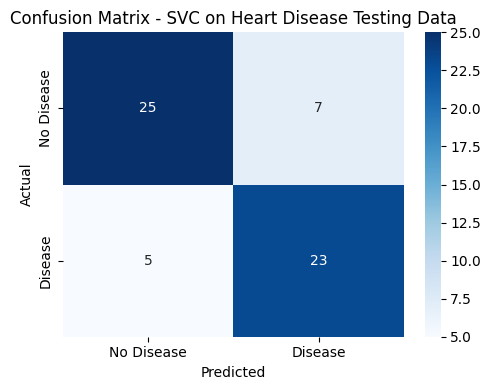

In [17]:
"""
Accuracy alone can be misleading, so we also report:
- Precision: of all patients predicted "Heart Disease", how many really had it?
- Recall: of all patients who really had heart disease, how many did the model catch?
- F1-score: harmonic mean of precision and recall.
- Confusion Matrix: correct vs. incorrect predictions per class.
"""

print("\nClassification Report:")
print("=======================\n")
print(classification_report(
    model_predictions["HeartDisease"],
    model_predictions["Predictions"],
    target_names=["No Heart Disease (0)", "Heart Disease (1)"]
))

conf_matrix = confusion_matrix(model_predictions["HeartDisease"], model_predictions["Predictions"])
conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual: No Heart Disease", "Actual: Heart Disease"],
    columns=["Predicted: No Heart Disease", "Predicted: Heart Disease"]
)
print("\nConfusion Matrix:")
print("==================\n")
print(conf_matrix_df)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVC on Heart Disease Testing Data")
plt.tight_layout()
plt.show()

### Step 8: Execute the Application Phase

#### Step 8.1: Take Input from User

In [18]:
"""
Purpose of this section:
-------------------------
Lets the user enter a patient's data. A demo patient is pre-filled so the notebook runs
top-to-bottom without typing. To enter your own values interactively, replace the four
demo lines with:
    gender_input = input("Please enter Gender (Male, Female): ").strip()
    exercise_angina_input = input("Please enter ExerciseAngina (No, Yes): ").strip()
    st_depression_input = input("Please enter STDepression (Absent, Mild, High): ").strip()
    vessels_input = input("Please enter Vessels (Zero, One, Two, Three): ").strip()
"""

# Demo patient (edit these values, or swap in input() calls as shown above)
gender_input = "Male"
exercise_angina_input = "Yes"
st_depression_input = "High"
vessels_input = "Two"

print(f"Gender: {gender_input}, ExerciseAngina: {exercise_angina_input}, STDepression: {st_depression_input}, Vessels: {vessels_input}")

Gender: Male, ExerciseAngina: Yes, STDepression: High, Vessels: Two


### Step 8.2: Convert User Input into Feature Vector (Exactly Same as Feature Vectors of Sample Data)

In [19]:
user_input = pd.DataFrame({
    "Gender": [gender_input],
    "ExerciseAngina": [exercise_angina_input],
    "STDepression": [st_depression_input],
    "Vessels": [vessels_input]
})

print("\n\nUser Input Feature Vector:")
print("==========================\n")
print(user_input)



User Input Feature Vector:

  Gender ExerciseAngina STDepression Vessels
0   Male            Yes         High     Two


### Step 8.3: Label Encoding of Feature Vector (Exactly Same as Label Encoded Feature Vectors of Sample Data)

In [20]:
unseen_data_features = user_input.copy()

unseen_data_features["Gender"] = gender_label_encoder.transform(user_input["Gender"])
unseen_data_features["ExerciseAngina"] = exercise_angina_label_encoder.transform(user_input["ExerciseAngina"])
unseen_data_features["STDepression"] = st_depression_label_encoder.transform(user_input["STDepression"])
unseen_data_features["Vessels"] = vessels_label_encoder.transform(user_input["Vessels"])

print("\n\nUser Input Encoded Feature Vector:")
print("==================================\n")
print(unseen_data_features)



User Input Encoded Feature Vector:

   Gender  ExerciseAngina  STDepression  Vessels
0       1               1             1        2


### Step 8.4: Load the Saved Model

In [21]:
model = pickle.load(open("svc_trained_model.pkl", "rb"))

### Step 8.5: Model Prediction

#### Step 8.5.1: Apply Model on the Label Encoded Feature Vector of unseen instance and return Prediction to the User

In [22]:
predicted_heart_disease = model.predict(unseen_data_features)

if predicted_heart_disease == 1:
    prediction = "HEART DISEASE"
if predicted_heart_disease == 0:
    prediction = "NO HEART DISEASE"

pretty_table = PrettyTable()
pretty_table.add_column("       ** Prediction **       ", [prediction])

print(pretty_table)

+--------------------------------+
|        ** Prediction **        |
+--------------------------------+
|         HEART DISEASE          |
+--------------------------------+


### Step 9: Execute the Feedback Phase

#### Step 9.1: Collect Feedback from Users and Domain Experts on Performance of the Model Deployed in the Real World

In [23]:
"""
Step 9.1: Example feedback from a domain expert and student testers reviewing the
model's predictions on a few real-world-style cases.
"""

example_feedback = pd.DataFrame({
    "Reviewer": ["Domain Expert (Cardiology)", "Student Tester", "Student Tester"],
    "Case": [
        "Male, exercise angina, high ST depression, 2 vessels -> predicted HEART DISEASE",
        "Female, no exercise angina, no ST depression, 0 vessels -> predicted NO HEART DISEASE",
        "Female, exercise angina, no ST depression, 0 vessels -> predicted unexpected result",
    ],
    "Feedback": [
        "Consistent with clinical knowledge: exercise angina, ST depression and blocked vessels are classic risk indicators.",
        "Plausible: absence of all four risk markers matches a low-risk profile.",
        "Borderline cases are less reliable - only 4 coarse categorical attributes are used, so important information (age, cholesterol, chest pain type) is missing.",
    ],
})
print(example_feedback.to_string(index=False))

                  Reviewer                                                                                  Case                                                                                                                                                     Feedback
Domain Expert (Cardiology)       Male, exercise angina, high ST depression, 2 vessels -> predicted HEART DISEASE                                          Consistent with clinical knowledge: exercise angina, ST depression and blocked vessels are classic risk indicators.
            Student Tester Female, no exercise angina, no ST depression, 0 vessels -> predicted NO HEART DISEASE                                                                                      Plausible: absence of all four risk markers matches a low-risk profile.
            Student Tester   Female, exercise angina, no ST depression, 0 vessels -> predicted unexpected result Borderline cases are less reliable - only 4 coarse categorical attributes are

#### Step 9.2: Make a List of Potential Improvements

In [24]:
improvements = [
    "Use more input attributes (age, chest pain type, cholesterol, max heart rate) instead of only 4",
    "Keep numeric attributes (age, cholesterol, heart rate) as numbers with feature scaling instead of binning them",
    "Use cross-validation and the larger multi-hospital UCI data (Hungarian, Switzerland, VA) for a more reliable evaluation",
    "Compare more models (e.g. Random Forest, Gradient Boosting) and tune hyper-parameters",
    "Prefer high recall, because missing a patient who has heart disease is more costly than a false alarm",
]
for i, item in enumerate(improvements, 1):
    print(f"{i}. {item}")

1. Use more input attributes (age, chest pain type, cholesterol, max heart rate) instead of only 4
2. Keep numeric attributes (age, cholesterol, heart rate) as numbers with feature scaling instead of binning them
3. Use cross-validation and the larger multi-hospital UCI data (Hungarian, Switzerland, VA) for a more reliable evaluation
4. Compare more models (e.g. Random Forest, Gradient Boosting) and tune hyper-parameters
5. Prefer high recall, because missing a patient who has heart disease is more costly than a false alarm


#### Step 9.3: Improve the Model Based on Feedback

In [25]:
print("Next version: retrain with more attributes (age, chest pain type, cholesterol) and cross-validation, then re-evaluate before replacing svc_trained_model.pkl")

Next version: retrain with more attributes (age, chest pain type, cholesterol) and cross-validation, then re-evaluate before replacing svc_trained_model.pkl


## Step 10: Deploy Your Model as a Public Web App

So far, running this notebook only lets *you* use the model, while Jupyter is open on your own computer. This section turns it into a **live website** that anyone can open in a browser. The deployment uses **Streamlit Community Cloud** (free), exactly like the Titanic live demo.

#### Step 10.1: Why Deploy a Model?
A trained model is only useful if people other than you can access it. A small web app lets non-technical users try the model without Python or Jupyter.

#### Step 10.2: Create a GitHub Account and Repository
1. Sign up at **https://github.com** (free).
2. Create a new **Public** repository (e.g. `heart-disease-predictor`).
3. Upload the contents of the `streamlit-app/` folder (`app.py`, `requirements.txt`, `runtime.txt`, `svc_trained_model.pkl`) — either with **Add file → Upload files**, or with git:
   ```
   git init
   git add .
   git commit -m "Heart disease predictor"
   git branch -M main
   git remote add origin https://github.com/<your-username>/heart-disease-predictor.git
   git push -u origin main
   ```

#### Step 10.3: Write a Simple Web App
The ready-made `streamlit-app/app.py` already does this. It (1) loads `svc_trained_model.pkl`, (2) recreates the same `LabelEncoder`s fitted on the same fixed category lists, (3) collects input with `st.selectbox`, and (4) calls `model.predict(...)` on a button click. Test it locally first:
```
cd streamlit-app
pip install -r requirements.txt
streamlit run app.py
```

#### Step 10.4: Create a Streamlit Community Cloud Account
Go to **https://share.streamlit.io** and **Sign in with GitHub**.

#### Step 10.5: Deploy Your App
1. **Create app → Deploy a public app from GitHub**.
2. Repository: `<your-username>/heart-disease-predictor`, Branch: `main`, Main file path: `app.py`.
3. Click **Deploy** and wait a minute or two. You get a public URL like `https://<something>.streamlit.app`.
4. **Paste this URL at the very top of this notebook** (first cell) before submitting.

#### Step 10.6: Troubleshooting Common Issues
- **`ModuleNotFoundError` although the package is in `requirements.txt`:** the default Python version has no prebuilt wheel for a pinned version. Open **Settings → General → Python version** and choose **3.11** or **3.12**.
- **Stuck on "Your app is in the oven":** click **Manage app**, read the build log, fix `requirements.txt`/Python version, then reboot.
- **`requirements.txt` ignored:** it must be in the same folder as `app.py`.
- **Pickle/version warnings:** keep the `scikit-learn` version in `requirements.txt` equal to the version used to train the model (`scikit-learn==1.7.2`).

#### Step 10.7: Share Your Live Link
Add the link to the top of this notebook and to your README.

---

## Conclusion
The analysis shows that heart disease in this dataset is strongly associated with exercise-induced angina, ST depression, the number of blocked vessels and gender: patients with more blocked vessels and exercise angina had a clearly higher disease rate (see Step 3.3). The Support Vector Classifier trained on only **four input attributes** reaches the accuracy reported in Step 7.4 on the held-out test set, with the precision, recall and confusion matrix shown in Step 7.5. The model is a teaching example built on a small dataset (297 patients) and must **not** be used for real medical decisions.